In [1]:
import os
import sys
import plotly.graph_objects as go

import matplotlib.pyplot as plt
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

from src.models.utils import *
import pandas as pd

In [2]:
from src.models.filter_data.filter_data import *
from src.models.filter_data.feature_adder import *


In [3]:
l_min = 4
max_diff = 3
c_thresh = 0.9

csv_read_path = os.path.join(project_root, "data", "processed", "integrated.csv")
csv_semi_write_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")

df = pd.read_csv(csv_read_path, encoding='utf-8')
df.dropna(subset=["generation"],inplace=True)

feature_adder = Feature_adder(df)
feature_adder.filter1()
feature_adder.filter2(l_min=l_min, max_diff=max_diff, initial_label=1)
feature_adder.filter3("temperature", c_thresh=c_thresh, initial_label=2)
feature_adder.add_interval_id(initial_label=3)
feature_adder.filter4(initial_label=3)
feature_adder.filter5(initial_label=4)

2025-10-15 17:38:06 - src.models.filter_data.feature_adder - INFO - 33.99% of rows have been chosen by filter1
2025-10-15 17:38:14 - src.models.filter_data.feature_adder - INFO - 57.47% of rows have been chosen by filter2
2025-10-15 17:38:41 - src.models.filter_data.feature_adder - INFO - 34.66% of rows have been chosen by filter3
2025-10-15 17:38:54 - src.models.filter_data.feature_adder - INFO - 92.33% of rows have been chosen by filter4
2025-10-15 17:38:54 - src.models.filter_data.feature_adder - INFO - 38.33% of rows have been chosen by filter5


In [4]:
import plotly.express as px
def show(df_m1,save=False,parm=None,ass=""):

    '''
    fig = px.scatter(df_m1, x="datetime", y='generation', color='color',
                    title='Generation over Time by Batch Interval',
                    labels={'generation': 'Generation', 'datetime': 'Time'},
                    hover_data=['datetime', 'generation', 'temperature','interval_id'])
    
    if save : fig.write_html(f"{project_root}/src/visualization/unit_figs/filter4{ass}/{parm['name']}-{parm['code']}.html")
    else : fig.show()
    '''
    
    fig = px.scatter(df_m1, x="temperature", y='generation', color='is_good_peak',
                title='Generation over Time by Batch Interval',
                labels={'generation': 'Generation'},
                hover_data=['generation', 'temperature'])
    if save: fig.write_html(f"{project_root}/src/visualization/unit_figs/filter4{ass}/{parm['name']}-{parm['code']}_s.html")
    else: fig.show()

In [5]:
name_plot = "پرند"
code_plot = "G12"
df_plot = feature_adder.df.copy()
ds_n_c_plot = Data_selector(Data_selector(df_plot).select_peaks(goodness=3))
df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
show(df_n_c_plot)

In [6]:
df_c = feature_adder.df.copy()

In [7]:
features = ["name", "code", "generation", "temp_sens", "is_good_peak"]
df_modified = df_c[features].copy(deep=True)
df_modified = df_modified[df_modified["is_good_peak"] >= 4]
df_modified = df_modified.dropna()
power_plants = df_modified[['name', 'code']].drop_duplicates()
gas_plants = power_plants[power_plants['code'].str.startswith("G")]

name = name_plot#row.name
code = code_plot#row.code
one_unit_df = df_modified[(df_modified['name'] == name) & (df_modified['code'] == code)]

sens_temps = one_unit_df['temp_sens'].values
gens = one_unit_df['generation'].values




sorted_idx = np.argsort(sens_temps)
sens_temps_sorted, gens_sorted = sens_temps[sorted_idx], gens[sorted_idx]

hist, bin_edges = np.histogram(sens_temps_sorted, bins=101)
group_indices = np.digitize(sens_temps_sorted, bin_edges) - 1
tuples = []

for g in np.unique(group_indices):
    mask = group_indices == g
    tuples.append((sens_temps_sorted[mask].mean(), find_95_max(gens_sorted[mask])))

X = np.array([a for a, b in tuples]).reshape(-1, 1)
y = np.array([b for a, b in tuples])
model = LinearRegression()
model.fit(X, y)




X_all = sens_temps.reshape(-1, 1)
y_pred_all = model.predict(X_all)

alpha = 2
beta = 5
is_in_area = (y_pred_all + alpha >= gens) & (gens >= y_pred_all - beta)

good_indices = one_unit_df[is_in_area].index
df_c.loc[good_indices, "is_good_peak"] = 5

In [8]:
ds_n_c_plot = Data_selector(Data_selector(df_c).select_peaks(goodness=4))
df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
fig = px.scatter(df_n_c_plot, x="temp_sens", y='generation', color='is_good_peak',
                title='Generation over Time by Batch Interval',
                labels={'generation': 'Generation'},
                hover_data=['generation', 'temperature'])
fig.show()

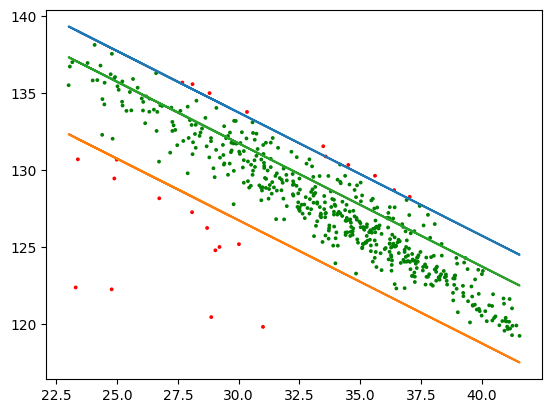

In [9]:
colors = ['green' if val else 'red' for val in is_in_area]
plt.scatter(X_all,gens,s=3,color=colors)

plt.plot(X_all,y_pred_all + alpha)
plt.plot(X_all,y_pred_all - beta)
plt.plot(X_all,y_pred_all)
